In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [21]:
os.chdir("/Users/sakshamrawat/Downloads")

df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [22]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 452.5 KB


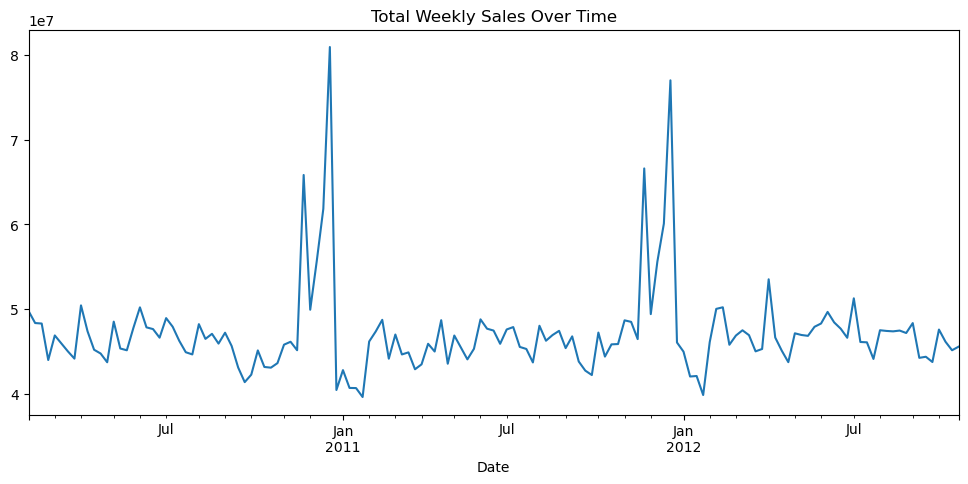

In [23]:
plt.figure(figsize=(12,5))
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Total Weekly Sales Over Time")
plt.show()

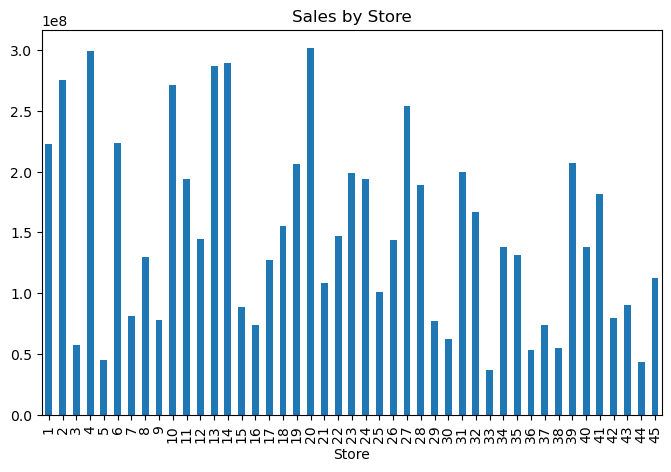

In [24]:
plt.figure(figsize=(8,5))
df.groupby('Store')['Weekly_Sales'].sum().plot(kind='bar')
plt.title("Sales by Store")
plt.show()

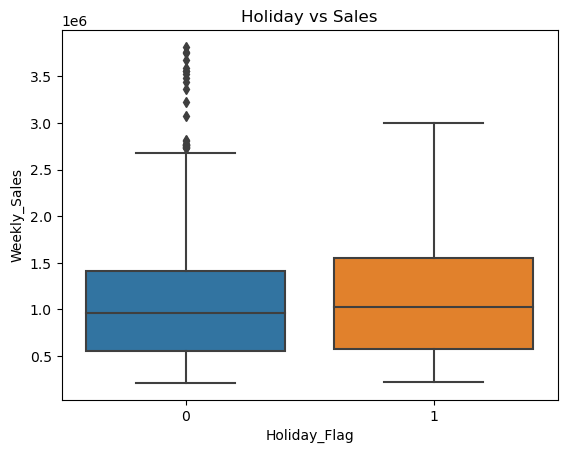

In [25]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Holiday vs Sales")
plt.show()

## Feature Engineering

In this step, new features are created from existing data to help the model understand patterns better. Time-based features such as year, month, and week are extracted from the date column.

In [26]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week.astype(int)

# Lag features
df['lag_1'] = df['Weekly_Sales'].shift(1)
df['lag_7'] = df['Weekly_Sales'].shift(7)

df = df.dropna()

### Lag Feature

Lag features are used to include past values of sales. This helps the model understand how previous sales influence future sales.

In [27]:
features = ['Store','Fuel_Price','CPI','Unemployment','Holiday_Flag',
            'year','month','week','lag_1','lag_7']

X = df[features]
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

## Data Preparation

The dataset is divided into input features (X) and target variable (y). This is required for training the machine learning model.

## Model Training

A Random Forest Regressor is used to train the model. It is an ensemble learning method that combines multiple decision trees to improve prediction accuracy.

In [28]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Prediction

The trained model is used to predict sales on the test dataset.

In [29]:
preds = model.predict(X_test)

## Model Evaluation

RMSE (Root Mean Square Error) is used to measure the difference between actual and predicted values. Lower RMSE indicates better performance.

In [31]:
rmse = mean_squared_error(y_test, preds, squared=False)
print("RMSE:", rmse)

RMSE: 221908.16304780915


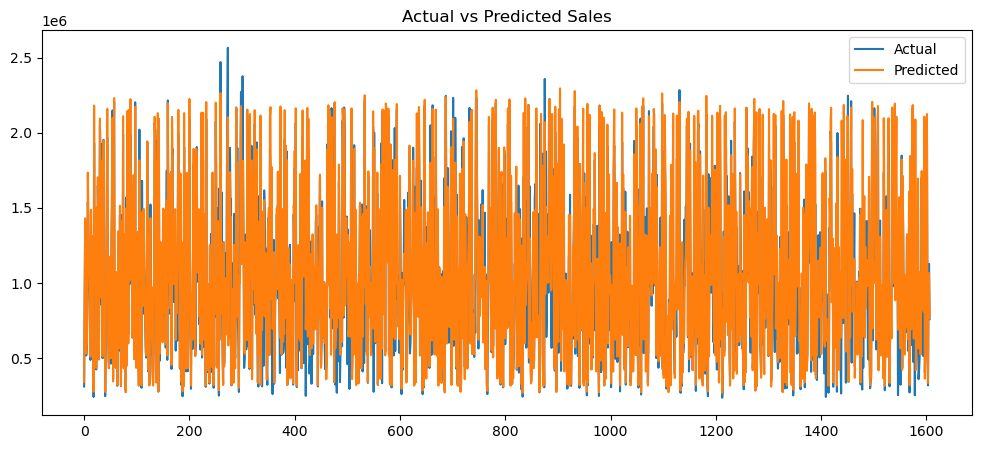

In [32]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

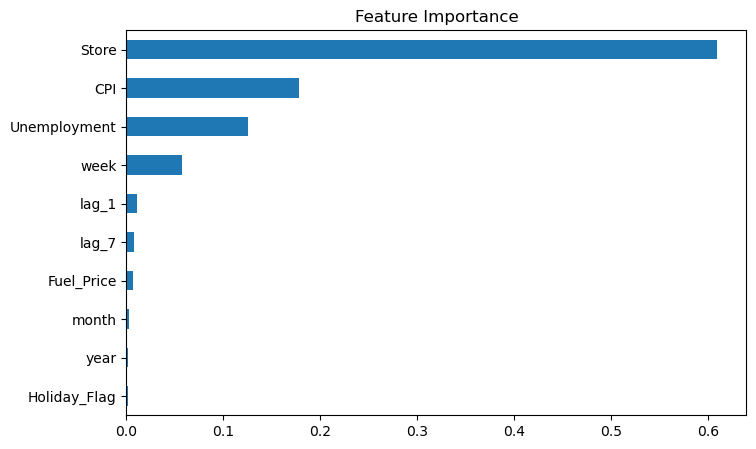

In [33]:
feat_importance = pd.Series(model.feature_importances_, index=features)
feat_importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

## Final Insights

- Sales show clear patterns across different stores and time periods  
- Store is the most influential feature in predicting sales  
- Lag feature helps capture past sales trends  
- The model performs reasonably well but may struggle with sudden fluctuations  